# Hybrid TPU + GDDR6-AiM Evaluation

This notebook evaluates an LLM workload on a hybrid architecture that combines a
TPU-style systolic array with a GDDR6-AiM (Accelerator-in-Memory) processing-in-memory
system. A `Fork` in the architecture lets the mapper assign each einsum to whichever
compute path is more efficient:

- **TPU path**: 128x128 systolic array with 128 MB global buffer (compute-bound ops)
- **AiM path**: 512 independent PUs with 32 GB/s per-bank DRAM (memory-bound ops)

## Setup

In [32]:
from pathlib import Path
import accelforge as af

examples_dir = Path("../examples")

HYBRID_ARCH = examples_dir / "arches" / "tpu_aim_hybrid.yaml"
WORKLOAD = examples_dir / "workloads" / "gpt3_small_hybrid.yaml"

BATCH_SIZE = 1
N_TOKENS = 1  # Decode phase: 1 token at a time

spec = af.Spec.from_yaml(
    HYBRID_ARCH,
    WORKLOAD,
    jinja_parse_data={"BATCH_SIZE": BATCH_SIZE, "N_TOKENS": N_TOKENS},
)

## Architecture

The hybrid architecture uses a `Fork` to split into two compute paths from shared
HBM main memory. The TPU path has a deep memory hierarchy (GlobalBuffer, LocalBuffer,
Register) feeding a 128x128 systolic array. The AiM path has 512 independent
processing units, each with its own 32 GB/s DRAM bank and 2 KB global buffer.

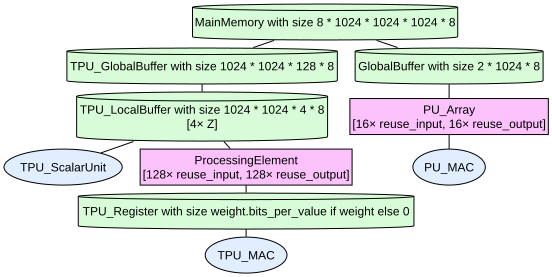

In [33]:
spec.arch

## Workload

GPT-3-like transformer with small ranks for fast mapper evaluation. Includes QKV
projections, attention (QK, softmax, AV), output projection, and FFN layers.
Rank ratios match GPT-3 6.7B scaled down by 64x.

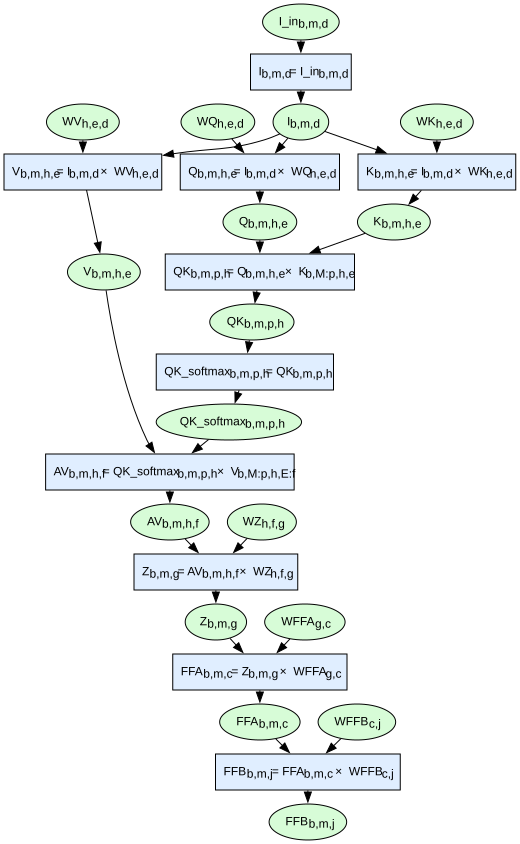

In [6]:
spec.workload

## Map Workload to Architecture

We map the full workload in a single call. The mapper jointly optimizes across all
einsums and automatically assigns each to the TPU or AiM path through the Fork.

In [34]:
spec.mapper.metrics = af.Metrics.LATENCY | af.Metrics.ENERGY
mapping = spec.map_workload_to_arch()
mapping

Getting energy, latency, and leak power for components running each Einsum. : 100%|██████████| 10/10 [00:03<00:00,  3.24it/s]
Generating pmapping templates for compute TPU_ScalarUnit Einsum I: 2it [00:00, 161.73it/s]
Generating pmapping templates for compute TPU_MAC Einsum I: 0it [00:00, ?it/s] ?it/s]
Generating pmapping templates for compute TPU_ScalarUnit Einsum V: 0it [00:00, ?it/s]
Generating pmapping templates for compute PU_MAC Einsum I: 3it [00:00, 223.76it/s]t/s], ?it/s]
Generating pmapping templates for compute TPU_ScalarUnit Einsum K: 0it [00:00, ?it/s]
Generating pmapping templates for compute TPU_ScalarUnit Einsum Q: 0it [00:00, ?it/s]
Generating pmapping templates for compute TPU_ScalarUnit Einsum FFA: 0it [00:00, ?it/s]
Generating pmapping templates for compute TPU_ScalarUnit Einsum QK: 0it [00:00, ?it/s]
Generating pmapping templates for compute TPU_ScalarUnit Einsum Z: 0it [00:00, ?it/s]
Generating pmapping templates for compute TPU_ScalarUnit Einsum AV: 0it [00:00, ?it

ValueError: Einsum QK has a pmapping template that is missing tensors. Ensure that there is a storage node storing each tensor in the Einsum. Missing tensors: oset({'K'}). Pmapping template:
	[Q in GlobalBuffer]
	[QK in GlobalBuffer]

## Results

Helper to pick a single result when the mapper returns a Pareto set (list of
optimal trade-offs). We select the point with minimum latency.

In [22]:
def pick(val, idx=None):
    """If val is a list (Pareto set), pick element at idx (default: 0)."""
    if isinstance(val, list):
        return val[idx if idx is not None else 0]
    return val


def best_latency_idx(result):
    """Return index of Pareto point with minimum latency, or None if scalar."""
    lat = result.latency()
    if isinstance(lat, list):
        return min(range(len(lat)), key=lambda i: lat[i])
    return None


idx = best_latency_idx(mapping)
energy = pick(mapping.energy(), idx)
latency = pick(mapping.latency(), idx)

print(f"Energy:  {energy:.6e} J")
print(f"Latency: {latency:.6e} s ({latency * 1e6:.2f} us)")

Energy:  5.615505e-06 J
Latency: 1.624337e-07 s (0.16 us)


### Per-Component Energy and Latency

This shows which hardware components dominate energy and latency. Components prefixed
with `TPU_` belong to the systolic array path; `AiM_BankDRAM`, `GlobalBuffer`, and
`PU_MAC` belong to the AiM path.

In [23]:
energy_by_comp = mapping.energy(per_component=True)
latency_by_comp = mapping.latency(per_component=True)

print(f"{'Component':<25} {'Energy (J)':>14} {'Latency (s)':>14}")
print("-" * 55)
for comp in sorted(energy_by_comp, key=lambda c: -pick(energy_by_comp[c], idx)):
    e = pick(energy_by_comp[comp], idx)
    l = pick(latency_by_comp.get(comp, 0), idx)
    if e > 0 or l > 0:
        print(f"{comp:<25} {e:>14.6e} {l:>14.6e}")

Component                     Energy (J)    Latency (s)
-------------------------------------------------------
MainMemory                  5.543014e-06   1.605212e-07
TPU_GlobalBuffer            5.600256e-08   1.632813e-09
TPU_LocalBuffer             1.234893e-08   0.000000e+00
TPU_MAC                     4.139520e-09   7.619048e-09
TPU_ScalarUnit              0.000000e+00   1.264881e-10


### Per-Einsum Breakdown

Shows energy and latency for each operation, and which compute path was used.

In [24]:
energy_by_ein = mapping.energy(per_einsum=True)
latency_by_ein = mapping.latency(per_einsum=True)

# Determine which path each einsum uses by checking the mapping string
mapping_col = "Total<SEP>mapping"
has_mapping_col = mapping_col in mapping.data.columns

def detect_path(einsum_name):
    """Detect TPU vs AiM from the mapping string for a given einsum."""
    if has_mapping_col:
        row = mapping.data.iloc[0 if idx is None else idx]
        mapping_str = str(row.get(mapping_col, ""))
        # Check per-einsum mapping columns too
        ein_col = f"{einsum_name}<SEP>mapping"
        if ein_col in mapping.data.columns:
            mapping_str = str(row.get(ein_col, ""))
        if "TPU_MAC" in mapping_str or "TPU_ScalarUnit" in mapping_str:
            return "TPU"
        if "PU_MAC" in mapping_str:
            return "AiM"
    return "?"

print(f"{'Einsum':<15} {'Path':<6} {'Energy (J)':>14} {'Latency (s)':>14}")
print("-" * 55)

tpu_einsums, aim_einsums = [], []
for ein in energy_by_ein:
    e = pick(energy_by_ein[ein], idx)
    l = pick(latency_by_ein.get(ein, 0), idx)
    path = detect_path(ein)
    if path == "TPU":
        tpu_einsums.append(ein)
    elif path == "AiM":
        aim_einsums.append(ein)
    print(f"{ein:<15} {path:<6} {e:>14.6e} {l:>14.6e}")

print(f"\nTPU einsums: {', '.join(tpu_einsums) or 'none'}")
print(f"AiM einsums: {', '.join(aim_einsums) or 'none'}")

Einsum          Path       Energy (J)    Latency (s)
-------------------------------------------------------
I               TPU      9.123839e-09   2.084691e-10
V               TPU      4.665139e-07   1.334202e-08
K               TPU      4.665139e-07   1.334202e-08
Q               TPU      4.665139e-07   1.334202e-08
QK              TPU      4.596352e-09   9.523810e-10
QK_softmax      TPU      3.407360e-10   7.812500e-12
AV              TPU      5.057152e-09   9.523810e-10
Z               TPU      4.665139e-07   1.334202e-08
FFA             TPU      1.861095e-06   5.336808e-08
FFB             TPU      1.869236e-06   5.357655e-08

TPU einsums: I, V, K, Q, QK, QK_softmax, AV, Z, FFA, FFB
AiM einsums: none


## Visualizations

Energy breakdown by component, stacked by einsum.

(<Figure size 300x400 with 1 Axes>,
 [<Axes: title={'center': '0-m0'}, ylabel='Energy (J)'>])

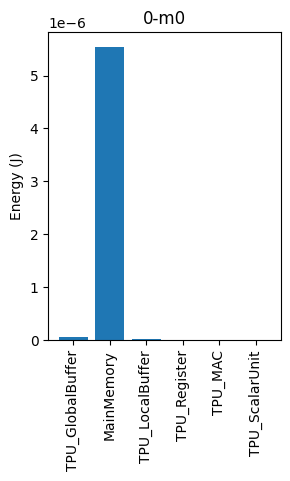

In [15]:
from accelforge.plotting.mappings import plot_energy_breakdown

plot_energy_breakdown([mapping], separate_by=["component"])

(<Figure size 300x400 with 1 Axes>,
 [<Axes: title={'center': '0-m0'}, ylabel='Energy (J)'>])

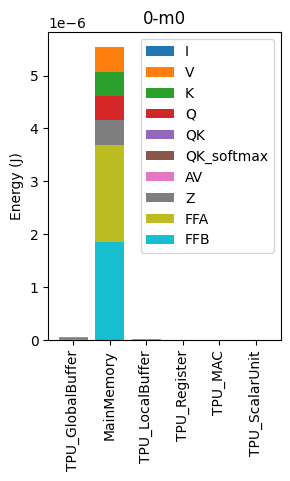

In [16]:
plot_energy_breakdown([mapping], separate_by=["component"], stack_by=["einsum"])

(<Figure size 300x400 with 1 Axes>,
 [<Axes: title={'center': '0-m0'}, ylabel='Energy (J)'>])

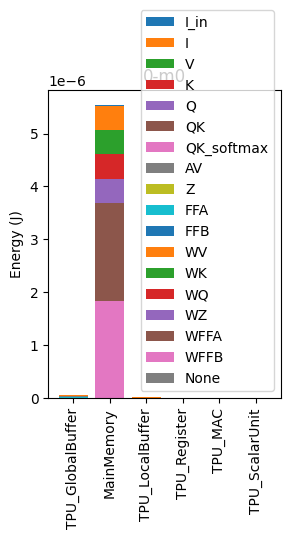

In [17]:
plot_energy_breakdown([mapping], separate_by=["component"], stack_by=["tensor"])

## Decode vs Prefill Comparison

During decode (M=1), operations are memory-bound and should favor AiM.
During prefill (M=128), operations become compute-bound and should favor the TPU.
We compare the two phases by re-mapping with different token counts.

In [18]:
results_by_phase = {}

for phase, tokens in [("Decode (M=1)", 1), ("Prefill (M=128)", 128)]:
    phase_params = {"BATCH_SIZE": BATCH_SIZE, "N_TOKENS": tokens}
    phase_spec = af.Spec.from_yaml(
        HYBRID_ARCH, WORKLOAD, jinja_parse_data=phase_params
    )
    phase_spec.mapper.metrics = af.Metrics.LATENCY | af.Metrics.ENERGY
    phase_mapping = phase_spec.map_workload_to_arch()

    phase_idx = best_latency_idx(phase_mapping)
    results_by_phase[phase] = {
        "mapping": phase_mapping,
        "energy": pick(phase_mapping.energy(), phase_idx),
        "latency": pick(phase_mapping.latency(), phase_idx),
    }
    print(f"{phase}: energy={results_by_phase[phase]['energy']:.4e} J, "
          f"latency={results_by_phase[phase]['latency']:.4e} s")

Getting energy, latency, and leak power for components running each Einsum. : 100%|██████████| 10/10 [00:03<00:00,  3.07it/s]
Generating pmapping templates for compute TPU_ScalarUnit Einsum Q: 0it [00:00, ?it/s]
Generating pmapping templates for compute TPU_ScalarUnit Einsum V: 0it [00:00, ?it/s]]
Generating pmapping templates for compute TPU_ScalarUnit Einsum I: 2it [00:00, 70.57it/s]
Generating pmapping templates for compute TPU_MAC Einsum I: 0it [00:00, ?it/s], ?it/s], ?it/s]
Generating pmapping templates for compute TPU_ScalarUnit Einsum K: 0it [00:00, ?it/s]
Generating pmapping templates for compute TPU_ScalarUnit Einsum QK: 0it [00:00, ?it/s]
Generating pmapping templates for compute TPU_ScalarUnit Einsum Z: 0it [00:00, ?it/s]
Generating pmapping templates for compute PU_MAC Einsum I: 3it [00:00, 128.23it/s]
Generating pmapping templates for compute TPU_ScalarUnit Einsum AV: 0it [00:00, ?it/s]
Generating pmapping templates for compute TPU_ScalarUnit Einsum FFA: 0it [00:00, ?it/s]

Einsum I has 5 pmapping jobs:
	0	[I_in in MainMemory] T-b  T-d  T-m  [I in TPU_GlobalBuffer] T-b  T-d  T-m  S-Z-m  S-Z-d  S-Z-b  TPU_ScalarUnit computes I
	1	[I_in in MainMemory] [I in MainMemory] T-b  T-d  T-m  S-Z-m  S-Z-d  S-Z-b  TPU_ScalarUnit computes I
	2	[I_in in MainMemory] [I in MainMemory] T-b  T-d  T-m  S-Y-m  S-Y-d  S-Y-b  S-X-m  S-X-d  S-X-b  PU_MAC computes I
	3	[I_in in MainMemory] T-b  T-d  T-m  [I in GlobalBuffer] T-b  T-d  T-m  S-Y-m  S-Y-d  S-Y-b  S-X-m  S-X-d  S-X-b  PU_MAC computes I
	4	[I_in in MainMemory] T-b  T-d  T-m  [I_in in GlobalBuffer] [I in GlobalBuffer] T-b  T-d  T-m  S-Y-m  S-Y-d  S-Y-b  S-X-m  S-X-d  S-X-b  PU_MAC computes I
Einsum V has 116 pmapping jobs:
	0	[WV in MainMemory] T-b  T-m  [I in TPU_GlobalBuffer] T-b  T-e  T-h  T-m  [V in TPU_GlobalBuffer] T-b  T-d  T-m  S-Z-m  S-Z-h  S-Z-e  S-Z-d  S-Z-b  [I in TPU_LocalBuffer] T-e  T-h  [V in TPU_LocalBuffer] T-d  S-reuse_output-d  S-reuse_input-h  S-reuse_input-e  [WV in TPU_Register] T-b  T-m  TPU_MAC

Compressing pmappings: 100%|██████████| 10/10 [00:00<00:00, 20.15it/s]


Dirty joining with resource usage <= 1.02× optimal
Dirty joining with objectives <= 2× optimal


Dirty pruning pmappings: 100%|██████████| 248/248 [00:00<00:00, 1500.50it/s]


...

Dirty joining uses 100.00% of the pmappings
Filtered 48856 -> 15187 (31.09% kept) pmappings


Final consolidate: 100%|██████████| 11/11 [00:00<00:00, 763.59it/s]
/Users/erik/Downloads/accelforge/accelforge/mapper/FFM/_join_pmappings/join_pmappings.py:348: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  joined.data[f"Total<SEP>{MAPPING_COLUMN}"] = [


Dirty joining mapping(s) valid & optimal! Returning...


/Users/erik/Downloads/accelforge/accelforge/mapper/FFM/_join_pmappings/join_pmappings.py:348: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  joined.data[f"Total<SEP>{MAPPING_COLUMN}"] = [


Prefill (M=128): energy=3.3702e-05 J, latency=7.0255e-07 s


In [ ]:
phase_mappings = [v["mapping"] for v in results_by_phase.values()]
phase_labels = list(results_by_phase.keys())

plot_energy_breakdown(
    phase_mappings,
    separate_by=["component"],
    stack_by=["einsum"],
    labels=phase_labels,
)